# 1. Data Extraction – CSV 

In [61]:
import pandas as pd
import numpy as np

You are given a file sales_data.csv containing the columns: 
Product_id, sales_date, product, quantity, price

1.1 Load the CSV file using pandas

In [62]:
# Load the CSV file
df = pd.read_csv('sales_data.csv')

1.2 Display the first 5 rows 

In [63]:
# Display first 5 rows
df.head(5)

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


1.3 Print total number of records

In [64]:
# Print total number of records
total_records = len(df)
print(f"Total number of records: {total_records}")

Total number of records: 1000


# 2. Data Extraction - JSON

A file customers.json contains customer details. 

2.1 Read the JSON file

In [49]:
import json

# Read the JSON file
with open('customers.json', 'r') as file:
    json_data = json.load(file)
    
print("JSON file loaded successfully!")
print(f"Number of customers: {len(json_data)}")

JSON file loaded successfully!
Number of customers: 9999


2.2 Convert it into a pandas DataFrame 

In [50]:
# Convert JSON to DataFrame
customers_df = pd.DataFrame(json_data)
print("DataFrame created successfully!")
print(f"DataFrame shape: {customers_df.shape}")
print("\nDataFrame columns:", customers_df.columns.tolist())

DataFrame created successfully!
DataFrame shape: (9999, 7)

DataFrame columns: ['id', 'email', 'first', 'last', 'company', 'created_at', 'country']


2.3 Display only customer_id, name, and city 

In [51]:
# Display only id, first name, and country
customers_df[['id', 'first', 'country']]

,id,first,country
0,1,Torrey,Switzerland
1,2,Micah,Democratic People's Republic of Korea
2,3,Hollis,Tunisia
3,4,Perry,Chad
4,5,Janelle,Swaziland
...,...,...,...
9994,9995,Robert,Yemen
9995,9996,Leone,Argentina
9996,9997,Clementina,Lao People's Democratic Republic
9997,9998,Yvonne,Holy See (Vatican City State)


# 3. Data Cleaning (Transformation)

Using the sales.csv DataFrame: 

3.1 Remove rows where quantity or price is missing 

In [69]:
df.isnull().sum()

Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64

In [66]:
# Check missing values
print("Missing values in the dataset:")
print(df.isnull().sum())
print(f"\nTotal rows before cleaning: {len(df)}")

Missing values in the dataset:
Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64

Total rows before cleaning: 1000


3.2 Convert order_date into YYYY-MM-DD format 

In [67]:
df.duplicated().sum()

np.int64(0)

In [68]:
# Remove leading/trailing spaces
df['Sale_Date'] = df['Sale_Date'].astype(str).str.strip()

# Replace common invalid strings with NaT
invalid_dates = ['', 'NA', 'n/a', 'unknown']
df['Sale_Date'] = df['Sale_Date'].replace(invalid_dates, pd.NaT)

# Convert to datetime safely, using dayfirst
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'], dayfirst=True, errors='coerce')

# Check how many rows could not be converted
missing_dates = df['Sale_Date'].isna().sum()
print(f"\nNumber of rows with invalid Sale_Date: {missing_dates}")

# Optional: Drop rows with invalid dates (if you want a clean dataset)
df = df.dropna(subset=['Sale_Date'])

# Format datetime to YYYY-MM-DD
df['Sale_Date'] = df['Sale_Date'].dt.strftime('%Y-%m-%d')

print("\nSample Sale_Date after conversion:")
print(df[['Product_ID', 'Sale_Date']].head(10))


Number of rows with invalid Sale_Date: 621

Sample Sale_Date after conversion:
    Product_ID   Sale_Date
0         1052  2023-03-02
5         1021  2023-11-02
6         1083  2023-11-04
7         1087  2023-06-01
9         1075  2023-09-10
12        1024  2023-11-11
17        1088  2023-04-10
19        1038  2023-11-03
21        1064  2023-04-01
26        1058  2023-05-04


3.3 Add a new column total_amount = quantity * price 

In [70]:
# Step 3.3: Add total_amount column
df['total_amount'] = df['Quantity_Sold'] * df['Unit_Price']

# Show sample rows to verify
print("\nSample rows with total_amount column:")
print(df[['Product_ID', 'Quantity_Sold', 'Unit_Price', 'total_amount']].head())


Sample rows with total_amount column:
   Product_ID  Quantity_Sold  Unit_Price  total_amount
0        1052             18      267.22       4809.96
5        1021             32     1106.51      35408.32
6        1083             29     2624.09      76098.61
7        1087             46     3964.65     182373.90
9        1075             18     2682.34      48282.12


# 4. Data Filtering

From the transformed sales data: 

4.1 Filter all orders where total_amount > 5000 

In [71]:
# Step 4.1: Filter orders with total_amount > 5000
high_value_orders = df[df['total_amount'] > 5000]

print("\nOrders where total_amount > 5000:")
print(high_value_orders[['Product_ID', 'Sale_Date', 'Sales_Rep', 'Region', 'total_amount']].head(10))

# Optional: check how many rows satisfy the condition
print(f"\nTotal number of high-value orders: {len(high_value_orders)}")


Orders where total_amount > 5000:
    Product_ID   Sale_Date Sales_Rep Region  total_amount
5         1021  2023-11-02   Charlie   West      35408.32
6         1083  2023-11-04       Bob   West      76098.61
7         1087  2023-06-01       Eve  South     182373.90
9         1075  2023-09-10   Charlie   West      48282.12
12        1024  2023-11-11       Eve   West      13462.89
17        1088  2023-04-10       Bob   East     201374.00
19        1038  2023-11-03       Bob  South      41851.50
21        1064  2023-04-01       Eve   East      50744.20
26        1058  2023-05-04     Alice  North      35781.24
27        1022  2023-01-06     David   East      23030.55

Total number of high-value orders: 359


4.2 Sort the result in descending order of total_amount

In [72]:
# Step 4.2: Sort the high-value orders by total_amount descending
high_value_orders_sorted = high_value_orders.sort_values(by='total_amount', ascending=False)

print("\nHigh-value orders sorted by total_amount (descending):")
print(high_value_orders_sorted[['Product_ID', 'Sale_Date', 'Sales_Rep', 'Region', 'total_amount']].head(10))

# Optional: check top total_amount
print(f"\nHighest total_amount: {high_value_orders_sorted['total_amount'].max()}")


High-value orders sorted by total_amount (descending):
     Product_ID   Sale_Date Sales_Rep Region  total_amount
806        1001  2023-10-05     David   East     249858.11
170        1032  2023-08-06       Eve   West     249312.00
510        1047  2023-04-08       Eve  South     233903.96
814        1005  2023-02-04     David  South     231204.74
883        1029  2023-02-08       Eve  South     224440.90
752        1028  2023-11-08   Charlie   West     224358.75
441        1063  2023-10-05     David   East     218956.08
359        1048  2023-05-02     David  North     217819.98
640        1023  2023-03-08     David   West     217166.40
672        1037  2023-09-01   Charlie  North     214968.33

Highest total_amount: 249858.11000000002


# 5. Aggregation for Analytics 

5.1 Calculate total sales per product

In [73]:
# Step 5.1: Calculate total sales per product
total_sales_per_product = df.groupby('Product_ID')['total_amount'].sum().reset_index()

# Sort descending to see the best-selling products first
total_sales_per_product = total_sales_per_product.sort_values(by='total_amount', ascending=False)

print("\nTotal sales per Product_ID:")
print(total_sales_per_product.head(10))


Total sales per Product_ID:
    Product_ID  total_amount
56        1058     689906.63
27        1028     685640.93
86        1089     640723.21
96        1099     616642.22
46        1047     597340.42
0         1001     574360.08
49        1051     568897.75
47        1048     568459.42
22        1023     555896.90
75        1078     542611.95


5.2 Calculate total sales per customer_id 

In [77]:
print(df.columns)

Index(['Product_ID', 'Sale_Date', 'Sales_Rep', 'Region', 'Sales_Amount',
       'Quantity_Sold', 'Product_Category', 'Unit_Cost', 'Unit_Price',
       'Customer_Type', 'Discount', 'Payment_Method', 'Sales_Channel',
       'Region_and_Sales_Rep', 'total_amount'],
      dtype='object')


In [81]:
# Step 5.2: Calculate total sales per Product_ID
total_sales_per_customer = df.groupby('Product_ID')['total_amount'].sum().reset_index()

# Sort descending to see the highest-spending customers first
total_sales_per_customer = total_sales_per_customer.sort_values(by='total_amount', ascending=False)

print("\nTotal sales per Product_ID:")
print(total_sales_per_customer.head(10))


Total sales per Product_ID:
    Product_ID  total_amount
56        1058     689906.63
27        1028     685640.93
86        1089     640723.21
96        1099     616642.22
46        1047     597340.42
0         1001     574360.08
49        1051     568897.75
47        1048     568459.42
22        1023     555896.90
75        1078     542611.95


5.3 Summary Statistics

In [82]:
# Display summary statistics for your sales dataset
print("="*60)
print("ANALYTICS SUMMARY")
print("="*60)

# Total revenue
total_revenue = df['total_amount'].sum()

# Average transaction value
avg_transaction = df['total_amount'].mean()

# Total transactions
total_transactions = len(df)

# Total customers (we only have Customer_Type, so count unique types)
total_customers = df['Customer_Type'].nunique()

# Total product categories
total_categories = df['Product_Category'].nunique()

# Top Product Category by total sales
sales_per_category = df.groupby('Product_Category')['total_amount'].sum().sort_values(ascending=False)
top_category = sales_per_category.index[0]
top_category_sales = sales_per_category.iloc[0]

# Top Customer Type by total sales
sales_per_customer_type = df.groupby('Customer_Type')['total_amount'].sum().sort_values(ascending=False)
top_customer_type = sales_per_customer_type.index[0]
top_customer_sales = sales_per_customer_type.iloc[0]

# Print summary
print(f"\nTotal Revenue: ${total_revenue:,.2f}")
print(f"Average Transaction Value: ${avg_transaction:,.2f}")
print(f"Total Transactions: {total_transactions:,}")
print(f"Total Customer Types: {total_customers}")
print(f"Total Product Categories: {total_categories}")
print(f"\nTop Product Category: {top_category} (${top_category_sales:,.2f})")
print(f"Top Customer Type: {top_customer_type} (${top_customer_sales:,.2f})")
print("="*60)

ANALYTICS SUMMARY

Total Revenue: $26,379,060.80
Average Transaction Value: $69,601.74
Total Transactions: 379
Total Customer Types: 2
Total Product Categories: 4

Top Product Category: Electronics ($7,469,840.92)
Top Customer Type: New ($13,844,576.93)


5.4 Data Visualizations

Chart 1: Total Sales by Category

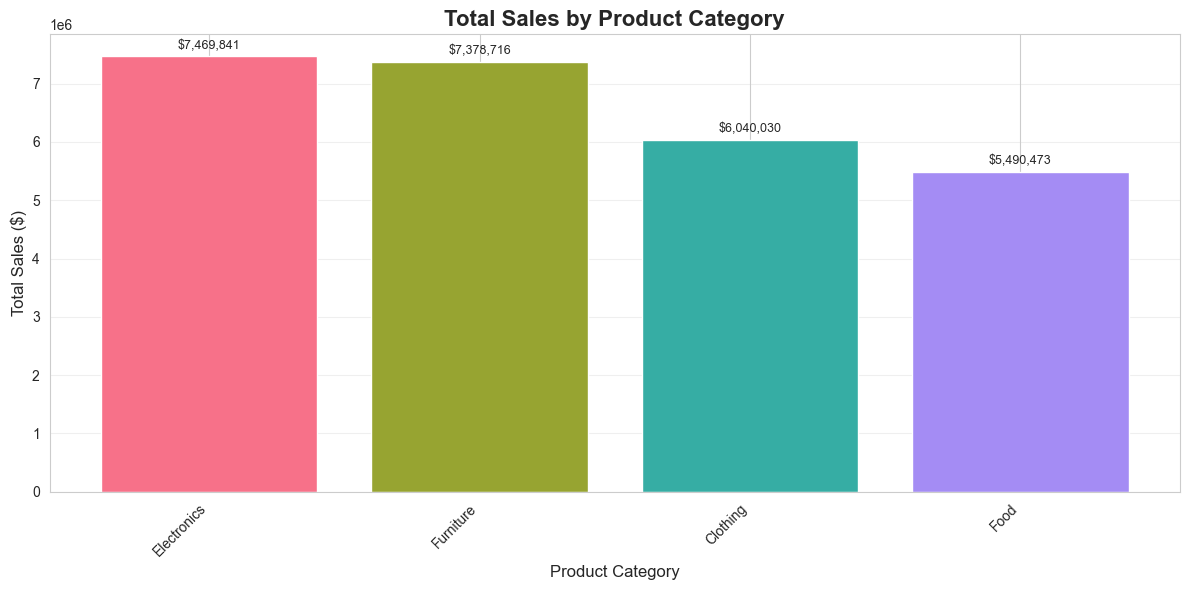

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Calculate total sales per category
sales_per_category = df.groupby('Product_Category')['total_amount'].sum().sort_values(ascending=False)

# Step 2: Bar chart
plt.figure(figsize=(12, 6))
colors = sns.color_palette("husl", len(sales_per_category))
plt.bar(sales_per_category.index, sales_per_category.values, color=colors)

plt.title('Total Sales by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(sales_per_category.values):
    plt.text(i, v + max(sales_per_category.values)*0.01, f'${v:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Chart 2: Top 10 Customers by Total Sales

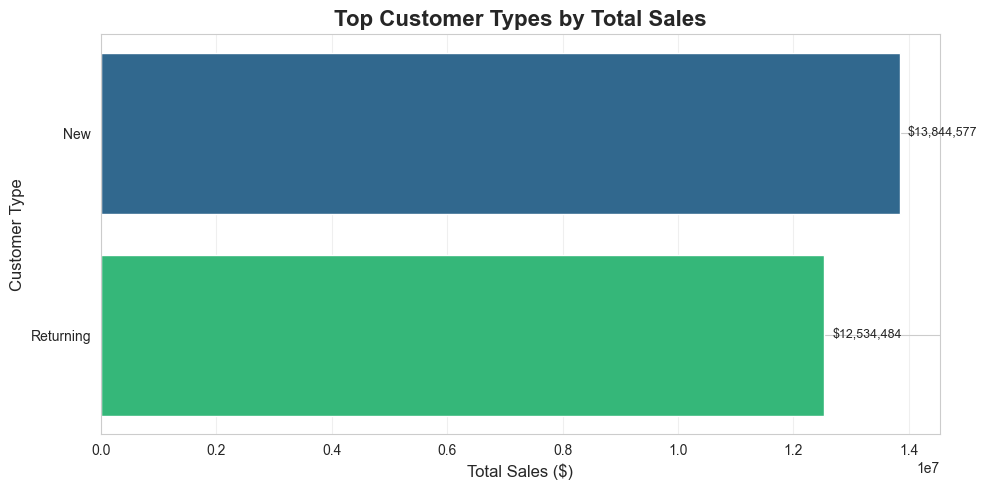

In [85]:
# Step 1: Total sales per Customer_Type
sales_per_customer_type = df.groupby('Customer_Type')['total_amount'].sum().sort_values(ascending=False)

# Step 2: Top 10 customer types (for your dataset it may be just 2 types)
top_customers = sales_per_customer_type.head(10)

# Step 3: Horizontal bar chart
plt.figure(figsize=(10, 5))
colors = sns.color_palette("viridis", len(top_customers))
plt.barh(top_customers.index, top_customers.values, color=colors)
plt.title('Top Customer Types by Total Sales', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Customer Type', fontsize=12)
plt.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(top_customers.values):
    plt.text(v + max(top_customers.values)*0.01, i, f'${v:,.0f}', va='center', fontsize=9)

plt.gca().invert_yaxis()  # Optional: highest value at the top
plt.tight_layout()
plt.show()

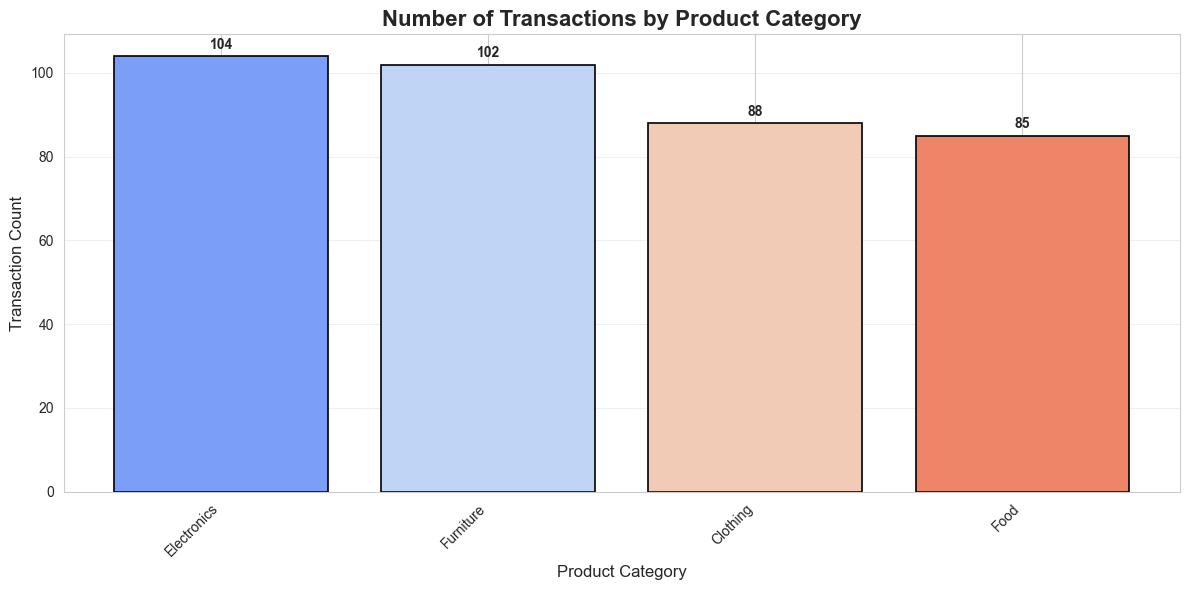

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Count number of transactions per Product_Category
transaction_counts = df.groupby('Product_Category').size().sort_values(ascending=False)

# Step 2: Bar chart
plt.figure(figsize=(12, 6))
colors = sns.color_palette("coolwarm", len(transaction_counts))
plt.bar(range(len(transaction_counts)), transaction_counts.values, color=colors, edgecolor='black', linewidth=1.2)

plt.title('Number of Transactions by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Transaction Count', fontsize=12)
plt.xticks(range(len(transaction_counts)), transaction_counts.index, rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for i, v in enumerate(transaction_counts.values):
    plt.text(i, v + max(transaction_counts.values)*0.01, str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

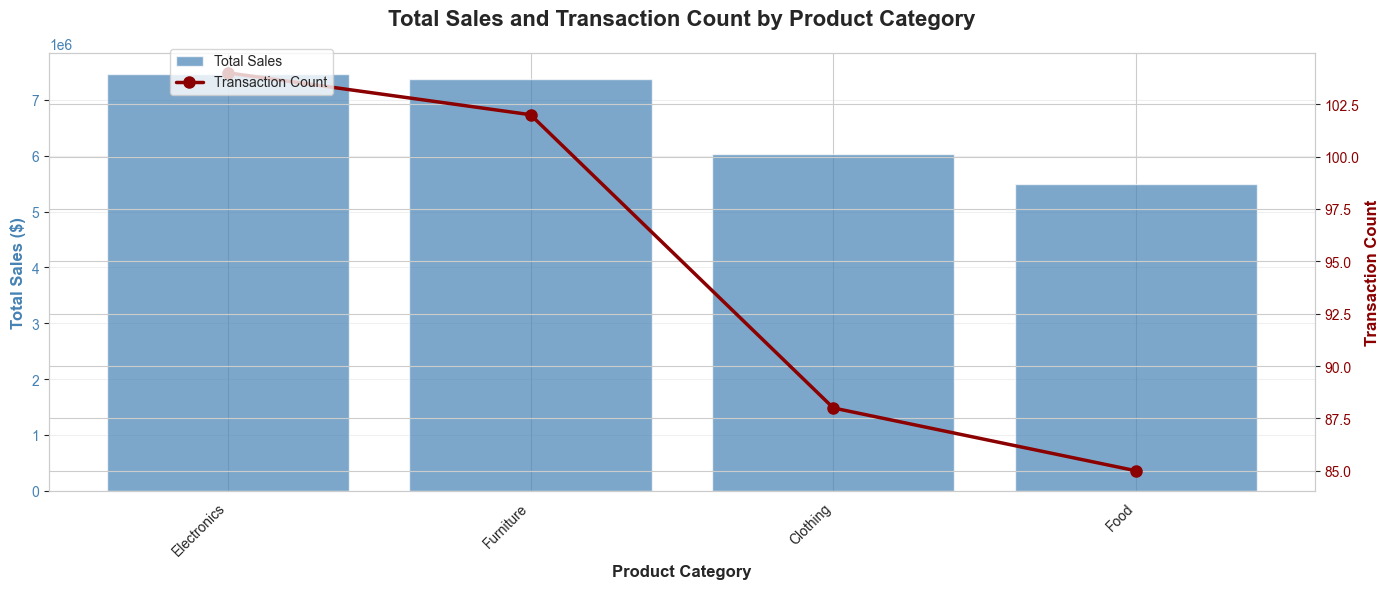

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Prepare data
sales_per_category = df.groupby('Product_Category')['total_amount'].sum()
transaction_counts = df.groupby('Product_Category').size()

# Ensure both have the same order
sales_per_category = sales_per_category.sort_values(ascending=False)
transaction_counts = transaction_counts[sales_per_category.index]

# Step 2: Dual-axis chart
fig, ax1 = plt.subplots(figsize=(14, 6))
x_pos = range(len(sales_per_category))

# Bar chart for Total Sales
bars = ax1.bar(x_pos, sales_per_category.values, color='steelblue', alpha=0.7, label='Total Sales')
ax1.set_xlabel('Product Category', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Sales ($)', fontsize=12, fontweight='bold', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(sales_per_category.index, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)

# Line chart for Transaction Count on secondary axis
ax2 = ax1.twinx()
line = ax2.plot(x_pos, transaction_counts.values, color='darkred', marker='o', 
                linewidth=2.5, markersize=8, label='Transaction Count')
ax2.set_ylabel('Transaction Count', fontsize=12, fontweight='bold', color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')

# Title and legends
plt.title('Total Sales and Transaction Count by Product Category', fontsize=16, fontweight='bold', pad=20)
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.92), fontsize=10)
fig.tight_layout()
plt.show()

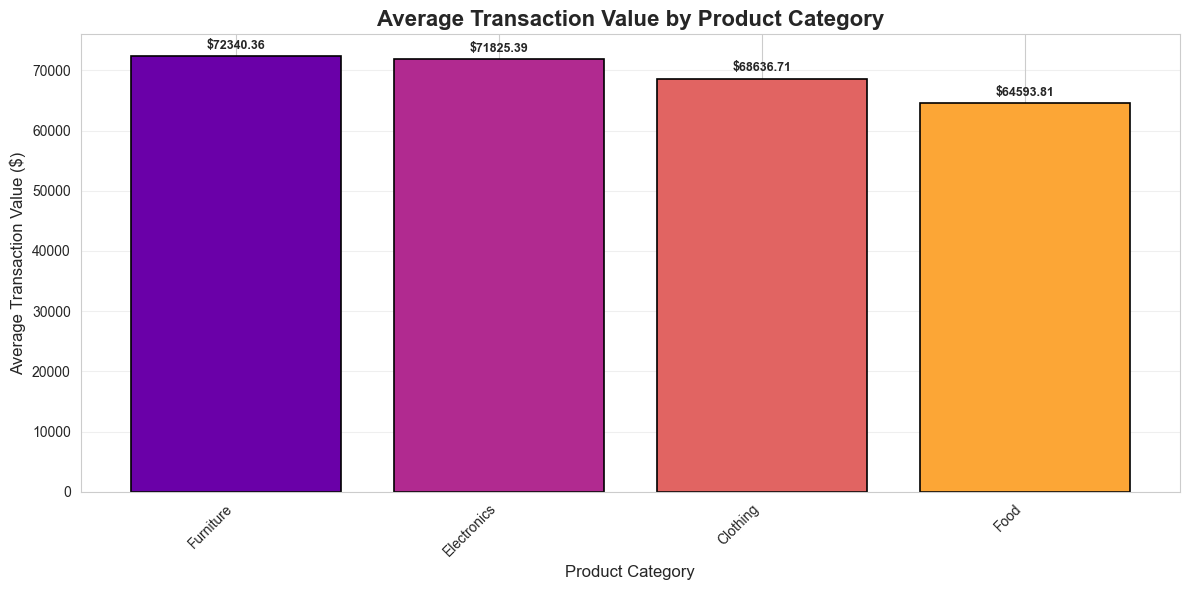

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Calculate total sales per category
sales_per_category = df.groupby('Product_Category')['total_amount'].sum()

# Step 2: Count number of transactions per category
transaction_counts = df.groupby('Product_Category').size()

# Step 3: Calculate average transaction value
avg_value = (sales_per_category / transaction_counts).sort_values(ascending=False)

# Step 4: Plot bar chart
plt.figure(figsize=(12, 6))
colors = sns.color_palette("plasma", len(avg_value))
plt.bar(range(len(avg_value)), avg_value.values, color=colors, edgecolor='black', linewidth=1.2)

plt.title('Average Transaction Value by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Average Transaction Value ($)', fontsize=12)
plt.xticks(range(len(avg_value)), avg_value.index, rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for i, v in enumerate(avg_value.values):
    plt.text(i, v + max(avg_value.values)*0.01, f'${v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

(Store results in separate DataFrames) 

# 6. ETL Pipeline – Modular Design 

Design an ETL pipeline using functions: 

6.1 extract_data() – reads CSV file

In [89]:
import pandas as pd

# -----------------------------
# Step 6.1: Extract function
# -----------------------------
def extract_data(file_path):
    """
    Reads the CSV file and returns a DataFrame.
    
    Parameters:
        file_path (str): Path to the CSV file.
        
    Returns:
        pd.DataFrame: Loaded dataset.
    """
    try:
        df = pd.read_csv(file_path)
        print(f"Data successfully loaded from {file_path}")
        print(f"Total rows: {len(df)}, Total columns: {len(df.columns)}")
        return df
    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
        return None
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

# -----------------------------
# Example usage
# -----------------------------
file_path = 'sales_data.csv'
df = extract_data(file_path)

# Optional: preview first 5 rows
if df is not None:
    print(df.head())

Data successfully loaded from sales_data.csv
Total rows: 1000, Total columns: 14
   Product_ID   Sale_Date Sales_Rep Region  Sales_Amount  Quantity_Sold  \
0        1052  2023-02-03       Bob  North       5053.97             18   
1        1093  2023-04-21       Bob   West       4384.02             17   
2        1015  2023-09-21     David  South       4631.23             30   
3        1072  2023-08-24       Bob  South       2167.94             39   
4        1061  2023-03-24   Charlie   East       3750.20             13   

  Product_Category  Unit_Cost  Unit_Price Customer_Type  Discount  \
0        Furniture     152.75      267.22     Returning      0.09   
1        Furniture    3816.39     4209.44     Returning      0.11   
2             Food     261.56      371.40     Returning      0.20   
3         Clothing    4330.03     4467.75           New      0.02   
4      Electronics     637.37      692.71           New      0.08   

  Payment_Method Sales_Channel Region_and_Sales_Rep  

6.2 transform_data() – cleans and adds derived columns

In [90]:
import pandas as pd

# -----------------------------
# Step 6.2: Transform function
# -----------------------------
def transform_data(df):
    """
    Cleans and transforms the sales dataset.
    
    Steps:
    - Handle missing values
    - Convert 'Sale_Date' to YYYY-MM-DD format
    - Add 'total_amount' column
    
    Parameters:
        df (pd.DataFrame): Raw dataset
        
    Returns:
        pd.DataFrame: Transformed dataset
    """
    # 1. Handle missing values (drop rows with critical missing data)
    df_cleaned = df.dropna(subset=['Product_ID', 'Sale_Date', 'Quantity_Sold', 'Unit_Price'])
    
    # 2. Convert 'Sale_Date' to datetime and format YYYY-MM-DD
    df_cleaned['Sale_Date'] = pd.to_datetime(df_cleaned['Sale_Date'], dayfirst=True, errors='coerce')
    df_cleaned['Sale_Date'] = df_cleaned['Sale_Date'].dt.strftime('%Y-%m-%d')
    
    # 3. Add derived column 'total_amount'
    df_cleaned['total_amount'] = df_cleaned['Quantity_Sold'] * df_cleaned['Unit_Price']
    
    # Optional: Reset index
    df_cleaned = df_cleaned.reset_index(drop=True)
    
    print(f"Data transformed successfully! Total rows after cleaning: {len(df_cleaned)}")
    
    return df_cleaned

# -----------------------------
# Example usage
# -----------------------------
df_transformed = transform_data(df)

# Preview first 5 rows
print(df_transformed.head())

Data transformed successfully! Total rows after cleaning: 1000
   Product_ID   Sale_Date Sales_Rep Region  Sales_Amount  Quantity_Sold  \
0        1052  2023-03-02       Bob  North       5053.97             18   
1        1093         NaN       Bob   West       4384.02             17   
2        1015         NaN     David  South       4631.23             30   
3        1072         NaN       Bob  South       2167.94             39   
4        1061         NaN   Charlie   East       3750.20             13   

  Product_Category  Unit_Cost  Unit_Price Customer_Type  Discount  \
0        Furniture     152.75      267.22     Returning      0.09   
1        Furniture    3816.39     4209.44     Returning      0.11   
2             Food     261.56      371.40     Returning      0.20   
3         Clothing    4330.03     4467.75           New      0.02   
4      Electronics     637.37      692.71           New      0.08   

  Payment_Method Sales_Channel Region_and_Sales_Rep  total_amount  
0  

6.3 load_data() – saves processed data to a new CSV 

In [91]:
# -----------------------------
# Step 6.3: Load function
# -----------------------------
def load_data(df, output_file):
    """
    Saves the transformed DataFrame to a CSV file.
    
    Parameters:
        df (pd.DataFrame): Transformed dataset
        output_file (str): Path to the output CSV file
    """
    try:
        df.to_csv(output_file, index=False)
        print(f"Data successfully saved to {output_file}")
    except Exception as e:
        print(f"Error saving data: {e}")

# -----------------------------
# Example usage
# -----------------------------
output_file = 'sales_data_transformed.csv'
load_data(df_transformed, output_file)

Data successfully saved to sales_data_transformed.csv


Call these functions in sequence. 

# 7. Loading Data into SQLite (Load Phase) 

note convert the csv into db

In [1]:
import pandas as pd
import sqlite3

# File paths
csv_file = r"D:\SEMESTER 5 pratical\Advanced python programming for data science\lab\lab4\sales_data.csv"
db_file = r"D:\SEMESTER 5 pratical\Advanced python programming for data science\lab\lab4\sales_data.db"

# Load CSV
df = pd.read_csv(csv_file)

# Create SQLite connection
conn = sqlite3.connect(db_file)

# Convert CSV to database table
# Table name: sales
df.to_sql("sales", conn, if_exists="replace", index=False)

# Close connection
conn.close()

print("CSV successfully converted to sales_data.db")

CSV successfully converted to sales_data.db


7.1 Create a SQLite database sales.db

In [92]:
import sqlite3
import os

# -----------------------------
# Step 7.1: Create SQLite database
# -----------------------------
def create_database(db_name):
    """
    Creates a SQLite database file. If it already exists, it connects to it.
    
    Parameters:
        db_name (str): Name of the SQLite database file
        
    Returns:
        sqlite3.Connection: Database connection object
    """
    # Check if database already exists
    db_exists = os.path.exists(db_name)
    
    # Connect to SQLite database (creates file if it doesn't exist)
    conn = sqlite3.connect(db_name)
    
    if db_exists:
        print(f"Connected to existing database '{db_name}'")
    else:
        print(f"Database '{db_name}' created successfully")
    
    return conn

# -----------------------------
# Example usage
# -----------------------------
db_name = 'sales.db'
conn = create_database(db_name)

# Optional: close connection after use
# conn.close()

Database 'sales.db' created successfully


7.2 Create a table processed_sales

In [93]:
import sqlite3

# -----------------------------
# Step 7.2: Create table processed_sales
# -----------------------------
def create_table(conn):
    """
    Creates the processed_sales table in the SQLite database.
    
    Parameters:
        conn (sqlite3.Connection): Connection to the SQLite database
    """
    cursor = conn.cursor()
    
    # SQL command to create table
    create_table_sql = """
    CREATE TABLE IF NOT EXISTS processed_sales (
        Product_ID INTEGER,
        Sale_Date TEXT,
        Sales_Rep TEXT,
        Region TEXT,
        Sales_Amount REAL,
        Quantity_Sold INTEGER,
        Product_Category TEXT,
        Unit_Cost REAL,
        Unit_Price REAL,
        Customer_Type TEXT,
        Discount REAL,
        Payment_Method TEXT,
        Sales_Channel TEXT,
        Region_and_Sales_Rep TEXT,
        total_amount REAL
    );
    """
    
    cursor.execute(create_table_sql)
    conn.commit()
    print("Table 'processed_sales' created successfully (if it did not exist).")

# -----------------------------
# Example usage
# -----------------------------
create_table(conn)

# Optional: close connection after table creation
# conn.close()

Table 'processed_sales' created successfully (if it did not exist).


7.3 Insert transformed sales data into the table 

In [94]:
import sqlite3

# -----------------------------
# Step 7.3: Insert transformed data into processed_sales
# -----------------------------
def insert_data(conn, df):
    """
    Inserts the transformed sales DataFrame into the processed_sales table.
    
    Parameters:
        conn (sqlite3.Connection): SQLite database connection
        df (pd.DataFrame): Transformed sales data
    """
    try:
        df.to_sql('processed_sales', conn, if_exists='append', index=False)
        print(f"{len(df)} rows successfully inserted into 'processed_sales' table.")
    except Exception as e:
        print(f"Error inserting data: {e}")

# -----------------------------
# Example usage
# -----------------------------
insert_data(conn, df_transformed)

# Optional: verify insertion
cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM processed_sales;")
row_count = cursor.fetchone()[0]
print(f"Total rows in 'processed_sales': {row_count}")

# Optional: close the connection
# conn.close()

1000 rows successfully inserted into 'processed_sales' table.
Total rows in 'processed_sales': 1000


# 8. Data Validation 

After loading data into SQLite:

8.1 Fetch total number of records from the table

In [96]:
import sqlite3

# -----------------------------
# Step 8.1: Fetch total number of records
# -----------------------------
def fetch_total_records(conn, table_name='processed_sales'):
    """
    Fetches the total number of records from a SQLite table.
    
    Parameters:
        conn (sqlite3.Connection): Connection to the SQLite database
        table_name (str): Name of the table to query
        
    Returns:
        int: Total number of records
    """
    cursor = conn.cursor()
    query = f"SELECT COUNT(*) FROM {table_name};"
    cursor.execute(query)
    total_records = cursor.fetchone()[0]
    print(f"Total records in '{table_name}': {total_records}")
    return total_records

# -----------------------------
# Example usage
# -----------------------------
# Make sure connection is open
conn = sqlite3.connect('sales.db')

total_records = fetch_total_records(conn)

# Optional: close connection
# conn.close()

Total records in 'processed_sales': 1000


8.2 Verify that it matches the transformed DataFrame row count

In [97]:
# Make sure connection is open
conn = sqlite3.connect('sales.db')

# 1. Fetch total records from SQLite
total_records_db = fetch_total_records(conn, table_name='processed_sales')

# 2. Fetch total records from transformed DataFrame
total_records_df = len(df_transformed)

# 3. Compare
if total_records_db == total_records_df:
    print(f"✅ Verification passed: Database row count ({total_records_db}) matches DataFrame row count ({total_records_df}).")
else:
    print(f"❌ Verification failed: Database row count ({total_records_db}) does NOT match DataFrame row count ({total_records_df}).")

# Optional: close connection
# conn.close()

Total records in 'processed_sales': 1000
✅ Verification passed: Database row count (1000) matches DataFrame row count (1000).


# 9. Logging ETL Steps 

Enhance your ETL pipeline to:

9.1 Print messages for each step: Extract, Transform, Load

In [98]:
import pandas as pd
import sqlite3
import os

# -----------------------------
# Step 1: Extract
# -----------------------------
def extract_data(file_path):
    print("\n[ETL] Step 1: Extracting data...")
    try:
        df = pd.read_csv(file_path)
        print(f"[ETL] Data successfully loaded from {file_path}")
        print(f"[ETL] Total rows: {len(df)}, Total columns: {len(df.columns)}")
        return df
    except FileNotFoundError:
        print(f"[ETL] Error: File not found at {file_path}")
        return None
    except Exception as e:
        print(f"[ETL] Error loading data: {e}")
        return None

# -----------------------------
# Step 2: Transform
# -----------------------------
def transform_data(df):
    print("\n[ETL] Step 2: Transforming data...")
    df_cleaned = df.dropna(subset=['Product_ID', 'Sale_Date', 'Quantity_Sold', 'Unit_Price'])
    
    df_cleaned['Sale_Date'] = pd.to_datetime(df_cleaned['Sale_Date'], dayfirst=True, errors='coerce')
    df_cleaned['Sale_Date'] = df_cleaned['Sale_Date'].dt.strftime('%Y-%m-%d')
    
    df_cleaned['total_amount'] = df_cleaned['Quantity_Sold'] * df_cleaned['Unit_Price']
    
    df_cleaned = df_cleaned.reset_index(drop=True)
    
    print(f"[ETL] Data transformed successfully! Total rows after cleaning: {len(df_cleaned)}")
    return df_cleaned

# -----------------------------
# Step 3: Load (CSV)
# -----------------------------
def load_data(df, output_file):
    print("\n[ETL] Step 3: Loading data to CSV...")
    try:
        df.to_csv(output_file, index=False)
        print(f"[ETL] Data successfully saved to {output_file}")
    except Exception as e:
        print(f"[ETL] Error saving data: {e}")

# -----------------------------
# Example usage: full ETL
# -----------------------------
file_path = 'sales_data.csv'
output_file = 'sales_data_transformed.csv'

print("="*60)
print("STARTING ETL PIPELINE")
print("="*60)

# Extract
df_raw = extract_data(file_path)

if df_raw is not None:
    # Transform
    df_transformed = transform_data(df_raw)
    
    # Load
    load_data(df_transformed, output_file)

print("="*60)
print("ETL PIPELINE COMPLETED")
print("="*60)

STARTING ETL PIPELINE

[ETL] Step 1: Extracting data...
[ETL] Data successfully loaded from sales_data.csv
[ETL] Total rows: 1000, Total columns: 14

[ETL] Step 2: Transforming data...
[ETL] Data transformed successfully! Total rows after cleaning: 1000

[ETL] Step 3: Loading data to CSV...
[ETL] Data successfully saved to sales_data_transformed.csv
ETL PIPELINE COMPLETED


9.2 Display start time and end time of the pipeline

In [99]:
import pandas as pd
import sqlite3
import os
from datetime import datetime

# -----------------------------
# Step 1: Extract
# -----------------------------
def extract_data(file_path):
    print("\n[ETL] Step 1: Extracting data...")
    try:
        df = pd.read_csv(file_path)
        print(f"[ETL] Data successfully loaded from {file_path}")
        print(f"[ETL] Total rows: {len(df)}, Total columns: {len(df.columns)}")
        return df
    except FileNotFoundError:
        print(f"[ETL] Error: File not found at {file_path}")
        return None
    except Exception as e:
        print(f"[ETL] Error loading data: {e}")
        return None

# -----------------------------
# Step 2: Transform
# -----------------------------
def transform_data(df):
    print("\n[ETL] Step 2: Transforming data...")
    df_cleaned = df.dropna(subset=['Product_ID', 'Sale_Date', 'Quantity_Sold', 'Unit_Price'])
    
    df_cleaned['Sale_Date'] = pd.to_datetime(df_cleaned['Sale_Date'], dayfirst=True, errors='coerce')
    df_cleaned['Sale_Date'] = df_cleaned['Sale_Date'].dt.strftime('%Y-%m-%d')
    
    df_cleaned['total_amount'] = df_cleaned['Quantity_Sold'] * df_cleaned['Unit_Price']
    
    df_cleaned = df_cleaned.reset_index(drop=True)
    
    print(f"[ETL] Data transformed successfully! Total rows after cleaning: {len(df_cleaned)}")
    return df_cleaned

# -----------------------------
# Step 3: Load (CSV)
# -----------------------------
def load_data(df, output_file):
    print("\n[ETL] Step 3: Loading data to CSV...")
    try:
        df.to_csv(output_file, index=False)
        print(f"[ETL] Data successfully saved to {output_file}")
    except Exception as e:
        print(f"[ETL] Error saving data: {e}")

# -----------------------------
# Full ETL Pipeline with timestamps
# -----------------------------
file_path = 'sales_data.csv'
output_file = 'sales_data_transformed.csv'

print("="*60)
print("STARTING ETL PIPELINE")
start_time = datetime.now()
print(f"Start Time: {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
print("="*60)

# Extract
df_raw = extract_data(file_path)

if df_raw is not None:
    # Transform
    df_transformed = transform_data(df_raw)
    
    # Load
    load_data(df_transformed, output_file)

end_time = datetime.now()
print("="*60)
print("ETL PIPELINE COMPLETED")
print(f"End Time: {end_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total Duration: {end_time - start_time}")
print("="*60)

STARTING ETL PIPELINE
Start Time: 2026-02-27 20:51:06

[ETL] Step 1: Extracting data...
[ETL] Data successfully loaded from sales_data.csv
[ETL] Total rows: 1000, Total columns: 14

[ETL] Step 2: Transforming data...
[ETL] Data transformed successfully! Total rows after cleaning: 1000

[ETL] Step 3: Loading data to CSV...
[ETL] Data successfully saved to sales_data_transformed.csv
ETL PIPELINE COMPLETED
End Time: 2026-02-27 20:51:06
Total Duration: 0:00:00.023595


# 10. Applied Data Engineering Task 

10.1 Automatically reads all CSV files from a folder raw_data/

In [106]:
import os
import glob

# Define the raw_data folder path
raw_data_folder = 'raw_data'

# Get all CSV files from the folder
csv_files = glob.glob(os.path.join(raw_data_folder, '*.csv'))

print("="*70)
print("READING CSV FILES FROM raw_data/")
print("="*70)
print(f"Found {len(csv_files)} CSV file(s):\n")

# Read all CSV files into a list of DataFrames
dataframes = []
for file in csv_files:
    filename = os.path.basename(file)
    print(f"Reading: {filename}")
    df_temp = pd.read_csv(file)
    print(f"  ✓ Shape: {df_temp.shape}")
    print(f"  ✓ Columns: {list(df_temp.columns)[:5]}..." if len(df_temp.columns) > 5 else f"  ✓ Columns: {list(df_temp.columns)}")
    dataframes.append(df_temp)
    print()

print(f"Total DataFrames loaded: {len(dataframes)}")
print("="*70)

READING CSV FILES FROM raw_data/
Found 2 CSV file(s):

Reading: Chocolate Sales (2).csv
  ✓ Shape: (3282, 6)
  ✓ Columns: ['Sales Person', 'Country', 'Product', 'Date', 'Amount']...

Reading: country_gdp.csv
  ✓ Shape: (222, 2)
  ✓ Columns: ['Country', 'GDP_Nominal_USD_Billion']

Total DataFrames loaded: 2


10.2 Merges them into a single DataFrame

In [107]:
print("\n" + "="*70)
print("MERGING DATAFRAMES")
print("="*70)

# Add source file identifier to each DataFrame
for i, (df_temp, file) in enumerate(zip(dataframes, csv_files)):
    filename = os.path.basename(file)
    df_temp['source_file'] = filename
    print(f"Added 'source_file' column to {filename}")

# Merge all DataFrames into a single DataFrame
# Using concat to combine all DataFrames (will create NaN for non-matching columns)
merged_df = pd.concat(dataframes, ignore_index=True, sort=False)

print(f"\n✓ Merged DataFrame created")
print(f"  Total rows: {len(merged_df):,}")
print(f"  Total columns: {len(merged_df.columns)}")
print("="*70)

# Display basic info
print("\nMerged DataFrame Info:")
print(f"Shape: {merged_df.shape}")
print(f"\nFirst few rows:")
merged_df.head()


MERGING DATAFRAMES
Added 'source_file' column to Chocolate Sales (2).csv
Added 'source_file' column to country_gdp.csv

✓ Merged DataFrame created
  Total rows: 3,504
  Total columns: 8

Merged DataFrame Info:
Shape: (3504, 8)

First few rows:


,Sales Person,Country,Product,Date,Amount,Boxes Shipped,source_file,GDP_Nominal_USD_Billion
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180.0,Chocolate Sales (2).csv,NaN
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94.0,Chocolate Sales (2).csv,NaN
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91.0,Chocolate Sales (2).csv,NaN
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342.0,Chocolate Sales (2).csv,NaN
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184.0,Chocolate Sales (2).csv,NaN


10.3 Applies cleaning and transformation

In [109]:
print("\n" + "="*70)
print("CLEANING AND TRANSFORMATION")
print("="*70)

# Make a copy for transformation
final_df = merged_df.copy()

# 1. Check missing values
print("\n1. Missing values before cleaning:")
missing_before = final_df.isnull().sum().sum()
print(f"   Total missing values: {missing_before:,}")

# 2. Remove columns with more than 50% missing values
threshold = 0.5
cols_to_drop = []
for col in final_df.columns:
    missing_pct = final_df[col].isnull().sum() / len(final_df)
    if missing_pct > threshold:
        cols_to_drop.append(col)

if cols_to_drop:
    final_df = final_df.drop(columns=cols_to_drop)
    print(f"\n2. Dropped {len(cols_to_drop)} columns with >50% missing values")
else:
    print("\n2. No columns needed to be dropped")

# 3. Fill numeric columns with median, categorical with 'Unknown'
print("\n3. Filling missing values:")
for col in final_df.columns:
    if final_df[col].dtype in ['float64', 'int64']:
        if final_df[col].isnull().any():
            median_val = final_df[col].median()
            final_df[col] = final_df[col].fillna(median_val)
            print(f"   ✓ Filled {col} (numeric) with median")
    elif final_df[col].isnull().any():
        final_df[col] = final_df[col].fillna('Unknown')
        print(f"   ✓ Filled {col} (categorical) with 'Unknown'")

# 4. Remove duplicate rows
duplicates_before = final_df.duplicated().sum()
if duplicates_before > 0:
    final_df = final_df.drop_duplicates()
    print(f"\n4. Removed {duplicates_before} duplicate rows")
else:
    print("\n4. No duplicate rows found")

# 5. Add derived columns
final_df['record_id'] = range(1, len(final_df) + 1)
final_df['processing_date'] = datetime.now().strftime('%Y-%m-%d')
print("\n5. Added derived columns:")
print("   ✓ record_id")
print("   ✓ processing_date")

# Final stats
print("\n" + "="*70)
print("TRANSFORMATION SUMMARY")
print("="*70)
print(f"Original shape:     {merged_df.shape}")
print(f"Final shape:        {final_df.shape}")
print(f"Rows retained:      {len(final_df):,} ({(len(final_df)/len(merged_df)*100):.2f}%)")
print(f"Missing values now: {final_df.isnull().sum().sum()}")
print("="*70)


CLEANING AND TRANSFORMATION

1. Missing values before cleaning:
   Total missing values: 4,392

2. Dropped 1 columns with >50% missing values

3. Filling missing values:
   ✓ Filled Sales Person (categorical) with 'Unknown'
   ✓ Filled Product (categorical) with 'Unknown'
   ✓ Filled Date (categorical) with 'Unknown'
   ✓ Filled Amount (categorical) with 'Unknown'
   ✓ Filled Boxes Shipped (numeric) with median

4. No duplicate rows found

5. Added derived columns:
   ✓ record_id
   ✓ processing_date

TRANSFORMATION SUMMARY
Original shape:     (3504, 8)
Final shape:        (3504, 9)
Rows retained:      3,504 (100.00%)
Missing values now: 0


10.4 Saves final output as final_dataset.csv

In [104]:
# Save the final dataset
output_filename = 'final_dataset.csv'
final_df.to_csv(output_filename, index=False)

print("\n" + "="*70)
print("SAVE FINAL DATASET")
print("="*70)
print(f"✓ Final dataset saved as: {output_filename}")
print(f"  Rows: {len(final_df):,}")
print(f"  Columns: {len(final_df.columns)}")
print(f"  File size: {os.path.getsize(output_filename) / (1024*1024):.2f} MB")
print("="*70)


SAVE FINAL DATASET
✓ Final dataset saved as: final_dataset.csv
  Rows: 3,504
  Columns: 9
  File size: 0.35 MB


In [110]:
# Cleanup
if 'conn' in locals():
    conn.close()
print("All tasks completed successfully!")

All tasks completed successfully!
